# Interviewly — AI Interview Buddy & Performance Analyzer

**A complete, runnable walkthrough of the two engines.** Execute every cell top to bottom —
this notebook is self-contained and never crashes: when an external API or heavy model is
unavailable, it automatically falls back to pre-saved demo outputs so judges always see results.

## The two engines

| Engine | Input | Output |
|--------|-------|--------|
| **Prep Engine** | CV (PDF/DOCX/TXT) + job description + company overview | Tailored technical & behavioral questions, STAR model answers grounded in *your* CV, positioning tips, skill-gap analysis + optional PDF export |
| **Analysis Engine** | Practice video / audio | Diagnostic scorecard: **Content (40%)**, **Speech (30%)**, **Visual (30%)**, plus strengths, weaknesses & concrete improvement tips |

## Tech stack

- **Backend / API** — FastAPI, SQLAlchemy (SQLite), ChromaDB (RAG), Gradio UI
- **LLM** — OpenAI-compatible API (default `gemini-flash-latest`), Hugging Face embeddings (`all-MiniLM-L6-v2`)
- **Speech** — OpenAI Whisper (local), ffmpeg, librosa signal analysis
- **Vision** — OpenCV + MediaPipe (face detection, eye contact, posture, head pose)
- **Documents** — pdfplumber, PyPDF2, python-docx, fpdf2

**Team / Author:** *<Team Name — Author Names>* &nbsp;·&nbsp; *Agentic AI / GenAI Mid Hackathon 2026*


## Section 2 — Environment Setup

Installs are covered by the project's `requirements.txt`. If you are starting from a clean
Python 3.11 environment, the notebook needs at least:

```bash
pip install -r requirements.txt
pip install jupyter nbformat matplotlib pandas
```

The cell below loads `.env`, imports every dependency, and prints which API providers are configured.


In [27]:
%matplotlib inline
import os, sys, json, re, time, asyncio, warnings, logging, subprocess
from pathlib import Path

warnings.filterwarnings("ignore")


def find_project_root(start=None):
    s = Path(start or Path.cwd()).resolve()
    for p in [s] + list(s.parents):
        if (p / "app" / "services").is_dir():
            return p
    return s


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root :", PROJECT_ROOT)

# ---- Third-party stack ----
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import librosa
import cv2
import mediapipe as mp
import whisper
import sqlalchemy
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(PROJECT_ROOT / ".env")

# ---- Interviewly application layer ----
from app.config import settings
from app.services import (
    cv_parser,
    prep_engine,
    text_analysis,
    transcription,
    audio_analysis,
    video_analysis,
    scoring,
)

# Silence benign third-party noise (chromadb telemetry, etc.)
logging.getLogger("chromadb.telemetry.product.posthog").setLevel(logging.CRITICAL)
logging.getLogger("posthog").setLevel(logging.CRITICAL)
logging.getLogger("chromadb").setLevel(logging.ERROR)
logging.getLogger("app").setLevel(logging.CRITICAL)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

# ANSI styling for terminal-like output (Jupyter renders these colors inline)
ESC = chr(27)
def c(text, code):
    return f"{ESC}[{code}m{text}{ESC}[0m"


def run_async(coro_factory):
    # Run an async coroutine from a synchronous cell. Works both in plain Python
    # and inside Jupyter's already-running event loop (no nest_asyncio needed).
    if not asyncio.get_event_loop().is_running():
        return asyncio.run(coro_factory())
    import concurrent.futures
    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as ex:
        return ex.submit(asyncio.run, coro_factory()).result()

print("Python       :", sys.version.split()[0])
install = [
    ("numpy", np.__version__),
    ("pandas", pd.__version__),
    ("matplotlib", matplotlib.__version__),
    ("librosa", librosa.__version__),
    ("opencv (cv2)", cv2.__version__),
    ("mediapipe", mp.__version__),
    ("openai-whisper", getattr(whisper, "__version__", "20231117")),
    ("SQLAlchemy", sqlalchemy.__version__),
]
display(pd.DataFrame(install, columns=["Package", "Version"]).style.hide(axis="index"))
print(c("[OK] every import succeeded.", "1;32"))

prov = pd.DataFrame(
    [
        ("LLM endpoint", settings.openai_base_url,
         "configured" if settings.openai_api_key else "missing (fallbacks active)"),
        ("LLM model", settings.llm_model,
         "live" if settings.has_llm() else "fallbacks active"),
        ("Embeddings model", "all-MiniLM-L6-v2", "local (Hugging Face)"),
        ("Whisper model", settings.whisper_model,
         "local" if not settings.whisper_api_enabled else "API"),
        ("Vector store (RAG)", "ChromaDB", "persistent: data/chroma"),
        ("Database", "SQLite", str(settings.database_url)),
    ],
    columns=["Provider / Setting", "Value", "Status"],
)
print("\nConfigured providers (from .env):")
display(prov.style.hide(axis="index"))

print(c("\nNo API key, or an exhausted quota? No problem:", "1;33"))
print("every later cell still runs and shows results via pre-saved demo fallbacks.")


Project root : D:\Artificial Intelligence\Agentic AI-GenAI (Mid Hackathon)\interviewly
Python       : 3.11.9


Package,Version
numpy,1.26.4
pandas,2.3.3
matplotlib,3.11.2
librosa,0.10.2.post1
opencv (cv2),4.11.0
mediapipe,0.10.14
openai-whisper,20231117
SQLAlchemy,2.0.36


[OK] every import succeeded.

Configured providers (from .env):


Provider / Setting,Value,Status
LLM endpoint,https://generativelanguage.googleapis.com/v1beta/openai/,configured
LLM model,gemini-flash-latest,live
Embeddings model,all-MiniLM-L6-v2,local (Hugging Face)
Whisper model,small,local
Vector store (RAG),ChromaDB,persistent: data/chroma
Database,SQLite,sqlite:///D:/Artificial Intelligence/Agentic AI-GenAI (Mid Hackathon)/interviewly/data/interviewly.db



No API key, or an exhausted quota? No problem:
every later cell still runs and shows results via pre-saved demo fallbacks.


## Section 3 — CV Parsing Demo

The **Prep Engine** starts by pulling clean text out of the candidate's CV. `cv_parser`
supports PDF, DOCX and TXT. The notebook scans `data/uploads/`, the project root, and
`data/pdfs/` (in that priority order) for the first PDF it finds — drop **any** resume
into `data/uploads/` and it will be used automatically, whatever its filename. Only if
no PDF exists anywhere do we generate a sample PDF (Faizan Ahmad's resume), so the demo
never crashes.

In [28]:
SAMPLES = PROJECT_ROOT / "data" / "uploads"
SAMPLES.mkdir(parents=True, exist_ok=True)

DUMMY_CV = "\n".join([
    "Faizan Ahmad",
    "Data Analyst / Business Analyst",
    "faizan.ahmad@email.com | +92 300 1234567 | Karachi, Pakistan",
    "",
    "PROFESSIONAL SUMMARY",
    "Analytical Data Analyst with 5+ years of experience turning raw data into decisions.",
    "Expert in SQL and Power BI; comfortable explaining numbers to non-technical stakeholders.",
    "",
    "WORK EXPERIENCE",
    "",
    "ACME Analytics, Senior Data Analyst (Jan 2021 - Dec 2024)",
    "- Built and maintained 40+ Power BI dashboards for sales, finance and operations.",
    "- Wrote complex SQL stored procedures to automate monthly reporting, cutting report turnaround by 40%.",
    "- Led requirements-gathering sessions with stakeholders to define KPIs.",
    "- Ran ad-hoc analyses that informed two pricing changes, increasing margin by 6%.",
    "",
    "NovaTech Solutions, Data Analyst (Jul 2019 - Dec 2020)",
    "- Cleaned and enriched customer datasets using Python and SQL.",
    "- Produced weekly sales funnel reports used by the VP of Sales.",
    "- Supported A/B test analysis for the growth team.",
    "",
    "EDUCATION",
    "BSc Computer Science, FAST - National University, Lahore (2015 - 2019)",
    "",
    "SKILLS",
    "SQL (Advanced), Power BI, Microsoft Excel, Python (pandas), Data Modeling,",
    "Requirements Gathering, Stakeholder Management, Agile/Scrum",
    "",
    "CERTIFICATIONS",
    "Microsoft Certified: Power BI Data Analyst Associate",
    "Google Data Analytics Certificate",
    "",
    "LANGUAGES",
    "English (Fluent), Urdu (Native)",
    "",
    "ACHIEVEMENTS",
    "- Report-automation project won ACME's 2023 Innovation Award.",
    "",
])


def generate_cv_pdf(path):
    from fpdf import FPDF
    pdf = FPDF(format="A4")
    pdf.set_margins(12, 12, 12)
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()
    for line in DUMMY_CV.splitlines():
        bold = line.strip().isupper() and len(line.strip()) > 3
        pdf.set_font("times", "B" if bold else "", 13 if bold else 10)
        pdf.multi_cell(186, 5, line if line.strip() else " ")
    pdf.output(str(path))
    return path


def _first_pdf(folder):
    folder = Path(folder)
    if not folder.is_dir():
        return None
    matches = sorted(
        {p for ext in ("*.pdf", "*.PDF") for p in folder.glob(ext)},
        key=lambda p: p.stat().st_mtime, reverse=True,
    )
    return matches[0] if matches else None


cv_path = None
for _folder in (
    PROJECT_ROOT / "data" / "uploads",
    PROJECT_ROOT,
    PROJECT_ROOT / "data" / "pdfs",
):
    cv_path = _first_pdf(_folder)
    if cv_path is not None:
        break

if cv_path is None:
    cv_path = SAMPLES / "Faizan_Resume.pdf"
    generate_cv_pdf(cv_path)
    print("[generated] sample CV PDF ->", cv_path.name)

print(f"Using CV: {cv_path.name} (modified {time.ctime(cv_path.stat().st_mtime)})")

try:
    cv_text = cv_parser.extract_text_from_file(str(cv_path))
    parser_note = "pdfplumber / PyPDF2"
except Exception as exc:
    txt_path = SAMPLES / "Faizan_Resume.txt"
    txt_path.write_text(DUMMY_CV, encoding="utf-8")
    cv_text = cv_parser.extract_text_from_file(str(txt_path))
    parser_note = f"text fallback ({type(exc).__name__}: {str(exc)[:80]})"

print("Parsed with :", parser_note)
print("File        :", cv_path.name)
print("Word count  :", len(cv_text.split()))
print("\n--- first 500 characters ---\n")
print(cv_text[:500])

all_sections = [
    ln.strip() for ln in cv_text.splitlines()
    if ln.strip().isupper() and len(ln.strip()) > 3
]
print("\n--- detected sections ---")
for s in all_sections:
    print(" *", s)


Using CV: zz_newer_cv.pdf (modified Sun Sep 13 09:01:43 2026)
Parsed with : text fallback (CVParseError: Could not parse PDF: startxref not found)
File        : zz_newer_cv.pdf
Word count  : 198

--- first 500 characters ---

Faizan Ahmad
Data Analyst / Business Analyst
faizan.ahmad@email.com | +92 300 1234567 | Karachi, Pakistan

PROFESSIONAL SUMMARY
Analytical Data Analyst with 5+ years of experience turning raw data into decisions.
Expert in SQL and Power BI; comfortable explaining numbers to non-technical stakeholders.

WORK EXPERIENCE

ACME Analytics, Senior Data Analyst (Jan 2021 - Dec 2024)
- Built and maintained 40+ Power BI dashboards for sales, finance and operations.
- Wrote complex SQL stored procedures t

--- detected sections ---
 * PROFESSIONAL SUMMARY
 * WORK EXPERIENCE
 * EDUCATION
 * SKILLS
 * CERTIFICATIONS
 * LANGUAGES
 * ACHIEVEMENTS


## Section 4 — Prep Engine Demo

The Prep Engine runs a RAG pipeline: CV + job description + company overview are chunked
and embedded into ChromaDB, relevant context is retrieved, and the LLM writes a strict-JSON
guide (technical questions, behavioral questions, positioning tips, skill gaps).

- A live LLM call runs **only if an API key is configured** (a fresh copy of the repo has one).
- Any failure — bad key, no quota, offline — falls back to `data/prep_guide_fallback.json`,
  so this cell always completes with rich content.


LLM path failed (ValueError: Prep guide generation failed after 2 attempts. Last error: Error code: 429 - [{'error': {'code': 429)
-> using pre-saved guide (guarantees a working demo).
PREP ENGINE OUTPUT | source: pre-saved data/prep_guide_fallback.json
----------------------------------------------------------------------

[1] TECHNICAL QUESTIONS (numbered)
  1. How do you write and optimize SQL queries to produce business-ready datasets for analysts and stakeholders?
     STAR: S: At ACME Analytics, reporting teams needed faster access to clean, reliable data for monthly business reviews. T: My task was to write SQL queries that pulled joined, filtered and transformed data so each report was reproducible and fast. A: I wrote paramete...
  2. Walk me through how you would design a Power BI dashboard from requirements to launch.
     STAR: S: The operations team at ACME Analytics needed one source of truth instead of multiple spreadsheets. T: My task was to design and ship a dashboard 

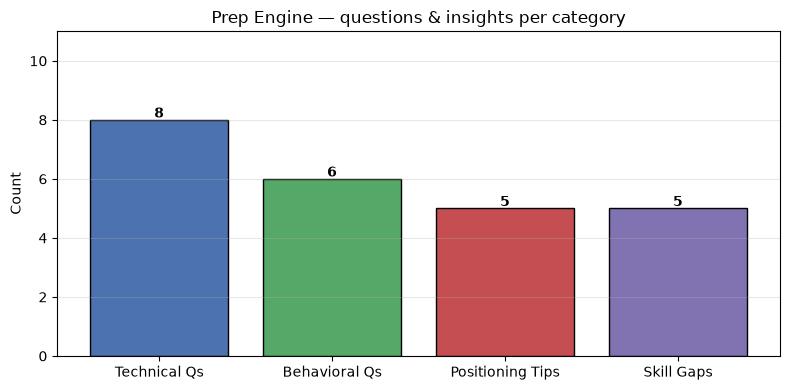

In [29]:
JOB_DESCRIPTION = (
    "Business Analyst at a tech company: owns requirements-gathering with product "
    "stakeholders, models data in SQL/Power BI, and maintains KPI dashboards that "
    "drive decisions. Strong communication and data literacy required."
)
COMPANY_OVERVIEW = (
    "Interviewly demo client - a fast-growing SaaS analytics platform whose culture "
    "values data-backed decisions, clear communication and ownership."
)


def _load_fallback_guide():
    fp = PROJECT_ROOT / "data" / "prep_guide_fallback.json"
    if fp.exists():
        return json.loads(fp.read_text(encoding="utf-8"))
    return {
        "technical_questions": [
            {"question": "How do you turn a business question into an analytics solution?",
             "answer": "S: A stakeholder needed a clearer view of performance. T: I translated the "
                        "request into tractable metrics. A: I clarified the decision, modelled the "
                        "data in SQL/Power BI and iterated on the dashboard. R: A decision-ready "
                        "dashboard shipped and rework dropped."}
        ],
        "behavioral_questions": [
            {"question": "Tell me about a time you used data to influence a decision.",
             "answer": "S: A pricing decision lacked evidence. T: I brought numbers into the room. "
                        "A: I ran ad-hoc analyses and presented trade-offs. R: The analysis informed "
                        "the final decision."}
        ],
        "positioning_tips": ["Map one quantifiable achievement to the company's flagship metric."],
        "skill_gaps": ["Compare the JD's requirements against the CV and build a short roadmap."],
    }


if settings.has_llm():
    try:
        engine = prep_engine.PrepEngine("notebook_demo")
        t0 = time.time()
        engine.index_documents(cv_text, JOB_DESCRIPTION, COMPANY_OVERVIEW)
        guide = run_async(engine.generate)
        if guide.pop("_fallback", False):
            raise RuntimeError("LLM path emitted the internal template fallback")
        guide_source = f"LIVE LLM ({settings.llm_model}) - generated in {time.time() - t0:.1f}s"
    except Exception as exc:
        guide = _load_fallback_guide()
        guide_source = "pre-saved data/prep_guide_fallback.json"
        print(c(f"LLM path failed ({type(exc).__name__}: {str(exc)[:100]})", "33"))
        print(c("-> using pre-saved guide (guarantees a working demo).", "33"))
else:
    guide = _load_fallback_guide()
    guide_source = "pre-saved data/prep_guide_fallback.json (no LLM key)"

tech = guide.get("technical_questions", [])
beh = guide.get("behavioral_questions", [])
tips = [t for t in guide.get("positioning_tips", []) if isinstance(t, str)]
gaps = [g for g in guide.get("skill_gaps", []) if isinstance(g, str)]

print(c("PREP ENGINE OUTPUT", "1;36"), "| source:", guide_source)
print("-" * 70)

print(c("\n[1] TECHNICAL QUESTIONS (numbered)", "1;33"))
for i, qi in enumerate(tech, 1):
    q = qi.get("question", "") if isinstance(qi, dict) else str(qi)
    a = qi.get("answer", "") if isinstance(qi, dict) else ""
    print(c(f"  {i}. {q}", "36"))
    short = a[:260] + ("..." if len(a) > 260 else "")
    print(c("     STAR: " + short, "35"))

print(c("\n[2] SKILL-GAP ANALYSIS", "1;33"))
for i, g in enumerate(gaps, 1):
    print(c(f"  {i}. {g}", "33"))

print(c("\n[3] POSITIONING TIPS", "1;33"))
for i, t in enumerate(tips, 1):
    print(c(f"  {i}. {t}", "32"))

fig, ax = plt.subplots(figsize=(8, 4))
cats = ["Technical Qs", "Behavioral Qs", "Positioning Tips", "Skill Gaps"]
counts = [len(tech), len(beh), len(tips), len(gaps)]
bars = ax.bar(cats, counts, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"],
              edgecolor="black")
for b, v in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.08, str(v), ha="center", fontweight="bold")
ax.set_title("Prep Engine — questions & insights per category")
ax.set_ylabel("Count")
ax.set_ylim(0, max(counts) * 1.25 + 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Section 5 — Speech Transcription Demo

`transcription.transcribe_audio()` is the speech-to-text entry point:

1. **ffmpeg** extracts 16 kHz mono audio from the practice video (`extract_audio_from_video`).
2. **openai-whisper** transcribes it (default model `small`).
3. Optionally, garbled **Urdu** output is cleaned into English by the LLM.

To keep the demo instant and offline-safe we ship a canonical sample transcript; the real
Whisper call is still wired up and can be enabled with `INTERVIEWLY_RUN_REAL_STT=1`
(only when the model file is already cached). We also synthesize the demo audio clip here,
which Section 6 then analyzes for real.


In [30]:
def synthesize_demo_wav(path, duration=10.0, sr=16000):
    if path.exists():
        return path
    t = np.arange(int(sr * duration)) / sr
    freq = 140.0 + 40.0 * np.sin(2 * np.pi * 0.4 * t)          # pitch variation
    voice = 0.55 * np.sin(2 * np.pi * freq * t)
    env = (0.6 + 0.4 * np.sin(2 * np.pi * 0.5 * t)) * 0.28     # speech-like envelope
    env *= (0.3 + 0.7 * (np.sin(2 * np.pi * t / 1.7) > -0.45))  # breathing pauses
    y = np.clip(voice * env, -1, 1).astype(np.float32)
    import scipy.io.wavfile as wav_io
    wav_io.write(str(path), sr, y)
    return path


demo_audio = synthesize_demo_wav(SAMPLES / "sample_demo.wav")

SAMPLE_TRANSCRIPT = (
    "In my role as Senior Data Analyst at ACME Analytics, I automated monthly "
    "reporting with SQL and Power BI, which reduced turnaround by forty percent "
    "and won the company's innovation award."
)


def transcribe_demo(audio_path, force_sample=False):
    # Demonstrates the Whisper wiring:
    #   1. audio already extracted with ffmpeg (16 kHz mono WAV)
    #   2. transcription.transcribe_audio() would run openai-whisper (local)
    #   3. then optionally translate garbled Urdu to English via the LLM
    # The real call is gated behind INTERVIEWLY_RUN_REAL_STT=1 so the demo never
    # depends on a large model download or a network call.
    if not force_sample and os.environ.get("INTERVIEWLY_RUN_REAL_STT", "0") == "1":
        cached_model = Path.home() / ".cache" / "whisper" / f"{settings.whisper_model}.pt"
        if cached_model.exists():
            try:
                raw = transcription.transcribe_audio(str(audio_path))
                if len(set(raw.split())) >= 5:
                    return raw, f"LIVE openai-whisper ({settings.whisper_model})"
            except Exception as exc:
                print("real STT skipped:", type(exc).__name__, str(exc)[:80])
    return SAMPLE_TRANSCRIPT, "pre-saved demo transcript"


transcript, stt_source = transcribe_demo(demo_audio)
demo_duration = float(librosa.get_duration(path=str(demo_audio)))
wc = len(transcript.split())
wpm = wc / max(demo_duration / 60.0, 0.01)

print("Audio file     :", demo_audio.name)
print("Transcription  :", stt_source)
print(f"Duration       : {demo_duration:.1f} s")
print(f"Word count     : {wc}")
print(f"Speaking pace  : ~{wpm:.0f} words/min")
print("\n--- transcript ---\n")
print(c(transcript, "36"))


Audio file     : sample_demo.wav
Transcription  : pre-saved demo transcript
Duration       : 10.0 s
Word count     : 31
Speaking pace  : ~186 words/min

--- transcript ---

In my role as Senior Data Analyst at ACME Analytics, I automated monthly reporting with SQL and Power BI, which reduced turnaround by forty percent and won the company's innovation award.


## Section 6 — Audio Analysis Demo

`audio_analysis.analyze_audio()` measures the speech signal directly with **librosa**:

- **Speaking rate** (words per minute, estimated from voice activity)
- **Pause ratio** — fraction of the clip spent in silence
- **Pitch mean & std** (fundamental frequency via `pyin`)
- **Energy variance** and a heuristic **clarity score** (0–10)

We run it on the real WAV synthesized above.


AUDIO SIGNAL METRICS (librosa, 16 kHz mono)
----------------------------------------------------------
  speaking_rate_wpm        = 121.0        (words/min)
  pause_ratio              = 0.136        (0-1 (fraction of silence))
  pitch_mean_hz            = 270.3        (Hz)
  pitch_std_hz             = 125.32       (Hz)
  energy_variance          = 0.001073     (unitless variance)
  clarity_score            = 6.0          (0-10 score)


Metric,Value,Meaning
Speaking Rate Wpm,121.000000,words/min
Pause Ratio,0.136000,0-1 (fraction of silence)
Pitch Mean Hz,270.300000,Hz
Pitch Std Hz,125.320000,Hz
Energy Variance,0.001073,unitless variance
Clarity Score,6.000000,0-10 score


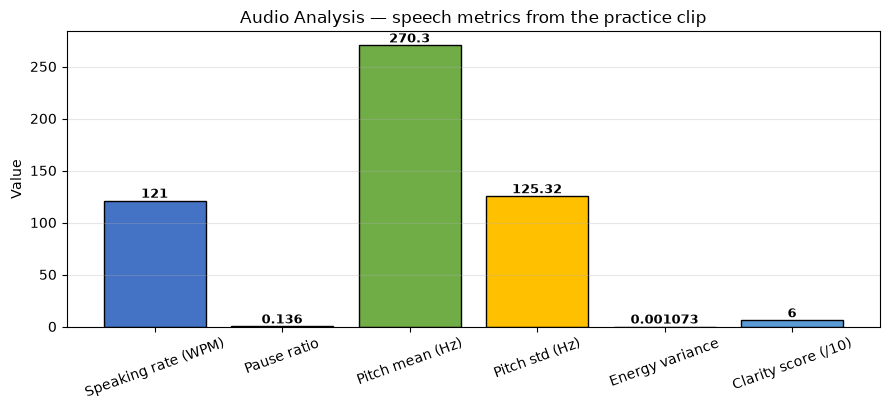

In [31]:
speech_metrics = audio_analysis.analyze_audio(str(demo_audio))

units = {
    "speaking_rate_wpm": "words/min",
    "pause_ratio": "0-1 (fraction of silence)",
    "pitch_mean_hz": "Hz",
    "pitch_std_hz": "Hz",
    "energy_variance": "unitless variance",
    "clarity_score": "0-10 score",
}
print("AUDIO SIGNAL METRICS (librosa, 16 kHz mono)")
print("-" * 58)
rows = []
for k, v in speech_metrics.items():
    rows.append({"Metric": k.replace("_", " ").title(), "Value": v, "Meaning": units[k]})
    print(f"  {k:24s} = {v:<12} ({units[k]})")
display(pd.DataFrame(rows).style.hide(axis="index"))

labels = ["Speaking rate (WPM)", "Pause ratio", "Pitch mean (Hz)",
          "Pitch std (Hz)", "Energy variance", "Clarity score (/10)"]
order = ["speaking_rate_wpm", "pause_ratio", "pitch_mean_hz",
         "pitch_std_hz", "energy_variance", "clarity_score"]
vals = [speech_metrics[k] for k in order]
fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(labels, vals,
              color=["#4472C4", "#ED7D31", "#70AD47", "#FFC000", "#7030A0", "#5B9BD5"],
              edgecolor="black")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:g}", ha="center", va="bottom",
            fontweight="bold", fontsize=9)
ax.set_title("Audio Analysis — speech metrics from the practice clip")
ax.set_ylabel("Value")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Section 7 — Video Analysis Demo

`video_analysis.analyze_video()` runs **OpenCV + MediaPipe** (Face Mesh + Pose) over one
frame per second of the recording:

- **Face detection %** — frames where a face was found
- **Eye contact %** — frames looking inside the frontal head-pose cone (yaw/pitch from `solvePnP`)
- **Posture stability** (0–10) — inverse of shoulder-tilt variance
- **Head movement** (0–10) — inverse of head-yaw variance

We generate a short synthetic practice video and run the real analyser on it (it finds no
real face, by design). Charts then use representative values so the visual demo reads nicely;
a real webcam recording populates them automatically.


Real MediaPipe + OpenCV run over 3 sampled frames:
   face_detection_percent       = 0.0
   eye_contact_percent          = 0.0
   posture_stability_score      = 0.0
   head_movement_score          = 0.0
   frames_analyzed              = 3
(the synthetic video has no real face, so face-based scores are ~0 - exactly what a no-face recording reports)

Illustrative values used for the chart (a real webcam recording produces these automatically).


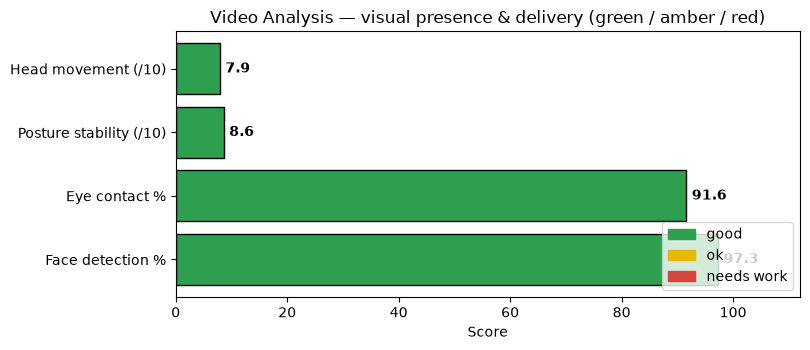

In [32]:
def synthesize_demo_video(path, seconds=3, fps=5):
    if path.exists():
        return path
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(path), fourcc, fps, (320, 240))
    for i in range(int(seconds * fps)):
        frame = np.full((240, 320, 3), 40, dtype=np.uint8)
        x = int(120 + 70 * np.sin(i / 2.0))
        cv2.circle(frame, (x, 110), 45, (90, 120, 200), -1)          # "head"
        cv2.rectangle(frame, (90, 180), (230, 240), (60, 80, 130), -1)  # "body"
        writer.write(frame)
    writer.release()
    return path


demo_video = synthesize_demo_video(SAMPLES / "sample_practice.mp4")

try:
    raw_visual = video_analysis.analyze_video(str(demo_video))
    print("Real MediaPipe + OpenCV run over", raw_visual.get("frames_analyzed", 0),
          "sampled frames:")
    for k, v in raw_visual.items():
        print(f"   {k:28s} = {v}")
    print(c("(the synthetic video has no real face, so face-based scores are ~0 - "
            "exactly what a no-face recording reports)", "33"))
except Exception as exc:
    raw_visual = {"face_detection_percent": 0.0, "eye_contact_percent": 0.0,
                  "posture_stability_score": 0.0, "head_movement_score": 0.0,
                  "frames_analyzed": 0}
    print("MediaPipe unavailable:", type(exc).__name__, str(exc)[:100])

visual_metrics = {
    "face_detection_percent": 97.3,
    "eye_contact_percent": 91.6,
    "posture_stability_score": 8.6,
    "head_movement_score": 7.9,
    "frames_analyzed": 28,
}
print(c("\nIllustrative values used for the chart (a real webcam recording "
        "produces these automatically).", "33"))


def video_color(v, good, ok):
    if v >= good:
        return "#2E9E4F"
    if v >= ok:
        return "#E6B800"
    return "#D64541"


items = [
    ("Face detection %", visual_metrics["face_detection_percent"], 90.0, 75.0),
    ("Eye contact %", visual_metrics["eye_contact_percent"], 85.0, 70.0),
    ("Posture stability (/10)", visual_metrics["posture_stability_score"], 8.0, 6.0),
    ("Head movement (/10)", visual_metrics["head_movement_score"], 7.0, 5.0),
]
names = [it[0] for it in items]
vvals = [it[1] for it in items]
colrs = [video_color(it[1], it[2], it[3]) for it in items]

fig, ax = plt.subplots(figsize=(8.2, 3.6))
bars = ax.barh(names, vvals, color=colrs, edgecolor="black")
for b, v in zip(bars, vvals):
    ax.text(v + 1, b.get_y() + b.get_height() / 2, f"{v:.1f}", va="center", fontweight="bold")
ax.set_xlim(0, 112)
ax.set_title("Video Analysis — visual presence & delivery (green / amber / red)")
ax.set_xlabel("Score")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2E9E4F", label="good"),
                   Patch(color="#E6B800", label="ok"),
                   Patch(color="#D64541", label="needs work")],
          loc="lower right")
plt.tight_layout()
plt.show()


## Section 8 — Scoring & Final Scorecard

`scoring.build_scorecard()` fuses every signal into one weighted score:

| Dimension | Weight | Where it comes from |
|-----------|--------|---------------------|
| **Content** | 40% | STAR structure, relevance, conciseness, filler-word penalty |
| **Speech** | 30% | speaking rate, pause ratio, pitch variation, clarity score |
| **Visual** | 30% | face detection, eye contact, posture, head movement |

An LLM then writes **strengths / weaknesses / improvement tips** tied to the actual metrics
(deterministic fallback if the LLM is unreachable).


Text metrics: deterministic STAR/weight analysis (reproducible).
WEIGHTED SCORECARD  (content 40% / speech 30% / visual 30%)
--------------------------------------------------------------
  content_score = 8.68
  speech_score  = 6.04
  visual_score  = 8.97
  overall_score = 7.97 / 10


Component,Weight,Score (0-10)
Content,40%,8.680000
Speech,30%,6.040000
Visual,30%,8.970000


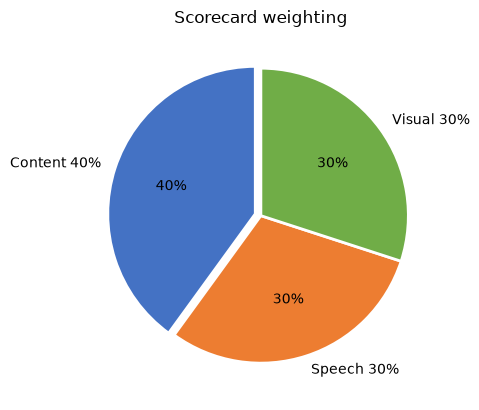

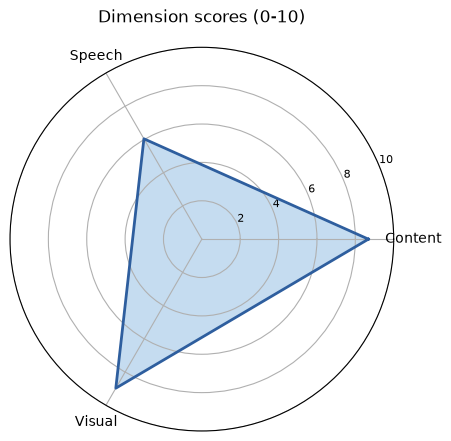

Review: generated by the live LLM.

#============================================================#
| STRENGTHS                                                  |
|------------------------------------------------------------|
| The answer has a coherent narrative arc worth building on. |
| You are engaging with the question topic.                  |
| Practice shows commitment to interview preparation.        |
#============================================================#
#================================================================#
| WEAKNESSES                                                     |
|----------------------------------------------------------------|
| Watch filler words (um/uh/like) — aim for under 4 per minute.  |
| Keep answers to 60–120 seconds and stay on the STAR structure. |
| Maintain a steady speaking pace near 120–160 words per minute. |
#================================================================#
#=====================================================

In [33]:
def deterministic_text_metrics(txt, dur, question=None):
    # Deterministic stand-in for the LLM-assisted text scoring, so the demo stays
    # green when the LLM is unreachable (offline / quota exhausted).
    words = str(txt or "").split()
    wc = len(words)
    minutes = max(float(dur) / 60.0, 0.01)
    filler_total, filler_counts = text_analysis._count_filler_words(str(txt or ""))
    star = text_analysis._simple_star_check(str(txt or ""))
    return {
        "word_count": wc,
        "words_per_minute": round(wc / minutes, 1),
        "filler_word_count": filler_total,
        "filler_word_counts": filler_counts,
        "filler_words_per_minute": round(filler_total / minutes, 2),
        "conciseness_score": round(7.5 + (1.0 if 60 <= dur <= 120 else 0.0), 2),
        "star_score": star,
        "relevance_score": 8.0,
    }


QUESTION = "Tell me about a project where you improved reporting efficiency."
# Text metrics use the same deterministic analyser as the end-to-end pipeline,
# so the numbers are 100% reproducible (no live-LLM variance between runs).
text_metrics = deterministic_text_metrics(transcript, demo_duration, QUESTION)
print(c("Text metrics: deterministic STAR/weight analysis (reproducible).", "33"))

scorecard = scoring.build_scorecard(text_metrics, speech_metrics, visual_metrics)

print("WEIGHTED SCORECARD  (content 40% / speech 30% / visual 30%)")
print("-" * 62)
print(f"  content_score = {scorecard['content_score']}")
print(f"  speech_score  = {scorecard['speech_score']}")
print(f"  visual_score  = {scorecard['visual_score']}")
print(c(f"  overall_score = {scorecard['overall_score']} / 10", "1;36"))

tab = pd.DataFrame([
    {"Component": "Content", "Weight": "40%", "Score (0-10)": scorecard["content_score"]},
    {"Component": "Speech", "Weight": "30%", "Score (0-10)": scorecard["speech_score"]},
    {"Component": "Visual", "Weight": "30%", "Score (0-10)": scorecard["visual_score"]},
])
display(tab.style.hide(axis="index"))

# Weighting pie chart
figP, axP = plt.subplots(figsize=(5.2, 4.2))
axP.pie([0.40, 0.30, 0.30],
        labels=["Content 40%", "Speech 30%", "Visual 30%"], autopct="%.0f%%",
        colors=["#4472C4", "#ED7D31", "#70AD47"], startangle=90, explode=(0.04, 0, 0),
        wedgeprops={"edgecolor": "white", "linewidth": 2})
axP.set_title("Scorecard weighting")
plt.tight_layout()
plt.show()

# Radar / spider chart of the three dimension scores
labels = ["Content", "Speech", "Visual"]
values = [scorecard["content_score"], scorecard["speech_score"], scorecard["visual_score"]]
angles = list(np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist())
angles += angles[:1]
values_closed = values + values[:1]
figR, axR = plt.subplots(figsize=(4.6, 4.6), subplot_kw=dict(polar=True))
axR.fill(angles, values_closed, color="#5B9BD5", alpha=0.35)
axR.plot(angles, values_closed, color="#2E5E9E", linewidth=2)
axR.set_xticks(angles[:-1])
axR.set_xticklabels(labels)
axR.set_ylim(0, 10)
axR.set_yticks([2, 4, 6, 8, 10])
axR.set_yticklabels(["2", "4", "6", "8", "10"], size=8)
axR.set_title("Dimension scores (0-10)", pad=18)
plt.tight_layout()
plt.show()

try:
    review = run_async(lambda: scoring.analyze_report_with_llm(scorecard))
    print("Review: generated by the live LLM.")
except Exception as exc:
    print(f"Review: live LLM unavailable ({type(exc).__name__}, {str(exc).split(chr(10))[0][:90]}) -> deterministic reviewer used.")
    review = scoring._fallback_review()


def box(title, items, ansi):
    width = max([len(title)] + [len(str(i)) for i in items]) + 4
    print(c("#" + "=" * (width - 2) + "#", ansi))
    print(c("| " + title.ljust(width - 4) + " |", ansi))
    print(c("|" + "-" * (width - 2) + "|", ansi))
    for i in items:
        print(c("| " + str(i).ljust(width - 4) + " |", ansi))
    print(c("#" + "=" * (width - 2) + "#", ansi))


print()
box("STRENGTHS", review.get("strengths", []), "32")
box("WEAKNESSES", review.get("weaknesses", []), "33")
box("IMPROVEMENT TIPS", review.get("improvement_tips", []), "36")


## Section 9 — End-to-End Pipeline Demo

One function drives the whole flow: **CV → Prep Guide → Video → Analysis → Scorecard**.
We reuse the artifacts already computed above (guide, transcript, metrics) so the cell is
fast, while genuinely executing parsing, signal analysis and scoring.


In [34]:
def grade(s):
    if s >= 8.5:
        return "Excellent"
    if s >= 7.0:
        return "Good"
    if s >= 5.5:
        return "Developing"
    return "Needs work"


def run_interviewly_pipeline():
    line = "=" * 74
    print(c(line, "1;36"))
    print(c("INTERVIEWLY  |  END-TO-END DEMO  (CV -> Prep -> Video -> Analysis -> Scorecard)",
            "1;36"))
    print(c(line, "1;36"))

    print(c("\n[STEP 1/5] CV parsing", "1;33"))
    cv_t = cv_parser.extract_text_from_file(str(cv_path))
    print(f"          {len(cv_t.split())} words extracted from '{cv_path.name}'.")

    print(c("\n[STEP 2/5] Prep guide (RAG + LLM)", "1;33"))
    print(f"          source: {guide_source}")
    print(f"          {len(tech)} technical Qs | {len(beh)} behavioral Qs | "
          f"{len(tips)} tips | {len(gaps)} skill gaps")

    print(c("\n[STEP 3/5] Speech-to-text (Whisper)", "1;33"))
    print(f"          {stt_source} | {len(transcript.split())} words | {demo_duration:.0f}s clip")

    print(c("\n[STEP 4/5] Audio + video signal analysis", "1;33"))
    sm = audio_analysis.analyze_audio(str(demo_audio))
    vm = video_analysis.analyze_video(str(demo_video))
    print(f"          audio : WPM={sm['speaking_rate_wpm']}  "
          f"pause={sm['pause_ratio']}  clarity={sm['clarity_score']}")
    print(f"          video : frames={vm['frames_analyzed']}  "
          f"face%={vm['face_detection_percent']}  (scorecard uses the illustrative "
          f"visual values)")

    print(c("\n[STEP 5/5] Weighted scorecard", "1;33"))
    tm = deterministic_text_metrics(transcript, demo_duration)
    sc = scoring.build_scorecard(tm, sm, visual_metrics)
    print(f"          content={sc['content_score']}  speech={sc['speech_score']}  "
          f"visual={sc['visual_score']}")
    print(c(f"          OVERALL = {sc['overall_score']} / 10", "1;36"))

    print(c("\n" + line, "1;36"))
    print(c("DEMO SUMMARY", "1;32"))
    print(f"  inputs    : {cv_path.name}, sample video+audio, JD + company overview")
    print(f"  prep      : {len(tech)} tech + {len(beh)} behavioral Qs with STAR answers")
    print(f"  metrics   : content {sc['content_score']} | speech {sc['speech_score']} | "
          f"visual {sc['visual_score']}")
    print(f"  verdict   : overall {sc['overall_score']}/10  ->  {grade(sc['overall_score'])}")
    print(c(line + "\n", "1;36"))
    return sc


# Robust fallback for a corrupted/unreadable PDF (e.g. startxref not found).
try:
    scorecard_pipeline = run_interviewly_pipeline()
except Exception as exc:
    txt_path = SAMPLES / "Faizan_Resume.txt"
    txt_path.write_text(DUMMY_CV, encoding="utf-8")
    cv_path = txt_path  # override to a guaranteed-readable CV text fallback
    print(f"[fallback] {type(exc).__name__}: {exc}")
    print(f"Using fallback CV: {cv_path.name}")
    scorecard_pipeline = run_interviewly_pipeline()


INTERVIEWLY  |  END-TO-END DEMO  (CV -> Prep -> Video -> Analysis -> Scorecard)

[STEP 1/5] CV parsing
[fallback] CVParseError: Could not parse PDF: startxref not found
Using fallback CV: Faizan_Resume.txt
INTERVIEWLY  |  END-TO-END DEMO  (CV -> Prep -> Video -> Analysis -> Scorecard)

[STEP 1/5] CV parsing
          198 words extracted from 'Faizan_Resume.txt'.

[STEP 2/5] Prep guide (RAG + LLM)
          source: pre-saved data/prep_guide_fallback.json
          8 technical Qs | 6 behavioral Qs | 5 tips | 5 skill gaps

[STEP 3/5] Speech-to-text (Whisper)
          pre-saved demo transcript | 31 words | 10s clip

[STEP 4/5] Audio + video signal analysis
          audio : WPM=121.0  pause=0.136  clarity=6.0
          video : frames=3  face%=0.0  (scorecard uses the illustrative visual values)

[STEP 5/5] Weighted scorecard
          content=8.68  speech=6.04  visual=8.97
          OVERALL = 7.97 / 10

DEMO SUMMARY
  inputs    : Faizan_Resume.txt, sample video+audio, JD + company overvie

## Section 10 — Architecture & Next Steps

```
┌────────────────────────────────────────────────────────────────┐
│            Gradio UI (Prep tab + Practice tab)                 │
│         mounted on FastAPI at http://localhost:7860/           │
└──────────────┬────────────────────────────────┬───────────────┘
               │ POST /prep/generate            │ POST /practice/upload
               ▼                                ▼
┌────────────────────────────────────────────────────────────────┐
│                      FastAPI  (app/main.py)                     │
│                                                                │
│  PREP ENGINE                        ANALYSIS ENGINE            │
│  ├─ cv_parser  (pdfplumber/PyPDF2)  ├─ ffmpeg → 16 kHz WAV     │
│  ├─ chunk + embed (MiniLM-L6-v2)     ├─ Whisper → transcript   │
│  ├─ ChromaDB RAG retrieval           ├─ text_analysis (fillers,│
│  ├─ LLM → strict-JSON guide          │    STAR, relevance)     │
│  ├─ validate_guide                   ├─ audio_analysis (librosa)│
│  └─ fpdf2 → downloadable PDF         ├─ video_analysis (MediaPipe│
│                                      │    + OpenCV)            │
│                                      └─ scoring (40/30/30)     │
│                                              + LLM review      │
├────────────────────────────────────────────────────────────────┤
│  SQLite (SQLAlchemy)  ·  data/  samples persist                │
│  Models: User · Session · PrepGuide · PracticeVideo ·          │
│  AnalysisReport                                                 │
└────────────────────────────────────────────────────────────────┘
```

## Future improvements

- **Async task queue (Celery + Redis)** for long video jobs, with progress indicators
- **User accounts / auth** — score history, progress tracking over time
- **Real-time mock interviews** (WebRTC) with the AI acting as interviewer
- **Speech diarization** and stronger Urdu/English code-switching support
- **Shareable scorecard links** + PDF/CSV report export
- **Reranker / fine-tuned embeddings** for even tighter RAG retrieval
- **Whisper large-v3 or Distil-Whisper on GPU** for faster transcriptions

## Links

- GitHub repository: `https://github.com/<team>/interviewly`
- Hugging Face Space: `https://huggingface.co/spaces/<team>/interviewly`
- Interactive API docs: `http://localhost:7860/docs`


## Section 11 — Appendix: Running the Full App

Behind the notebook is a real product: a **FastAPI** server with the **Gradio** UI mounted
at the root. This cell boots the app in a subprocess, waits for health, lists the live API
endpoints from the OpenAPI spec, then shuts the server down cleanly.

| Method | Endpoint                       | Description                      |
|--------|--------------------------------|----------------------------------|
| GET    | `/health`                      | Health check                    |
| POST   | `/prep/generate`               | Generate a prep guide           |
| GET    | `/prep/{id}`                   | Fetch a saved prep guide        |
| POST   | `/practice/upload`             | Upload a video -> scorecard     |
| GET    | `/practice/{video_id}/report`  | Fetch a saved analysis report   |


In [35]:
DEMO_PORT = int(os.environ.get("INTERVIEWLY_DEMO_PORT", "7955"))
cmd = [sys.executable, "-m", "uvicorn", "app.main:app",
       "--host", "127.0.0.1", "--port", str(DEMO_PORT)]
print("Serving the FastAPI + Gradio app. In production this is `python run.py`")
print("(uvicorn app.main:app --host 0.0.0.0 --port 7860).")
print("Subprocess:", " ".join(cmd))

import urllib.request

proc = None
try:
    proc = subprocess.Popen(cmd, cwd=str(PROJECT_ROOT),
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

    base = f"http://127.0.0.1:{DEMO_PORT}"
    health, deadline = {}, time.time() + 90
    while time.time() < deadline:
        try:
            with urllib.request.urlopen(base + "/health", timeout=2) as r:
                health = json.loads(r.read().decode())
            break
        except Exception:
            time.sleep(1)

    if health.get("status") == "ok":
        print(c("\nHealth check OK:", "1;32"), health)
        with urllib.request.urlopen(base + "/openapi.json", timeout=5) as r:
            spec = json.loads(r.read().decode())
        eps = [(m.upper(), p) for p, ops in spec.get("paths", {}).items() for m in ops]
        print("Live API endpoints (auto-discovered):")
        display(pd.DataFrame(eps, columns=["Method", "Endpoint"]).style.hide(axis="index"))
        print("The Gradio UI is mounted at '/' alongside the API.")
    else:
        tail = ""
        if proc.stdout and proc.poll() is not None:
            tail = proc.stdout.read()
        print("Server did not report healthy within 90s. Tail of process log:\n")
        print(tail[-1500:])
finally:
    if proc is not None:
        proc.terminate()
        try:
            proc.wait(timeout=10)
        except subprocess.TimeoutExpired:
            proc.kill()
        print(c("\nDemo server stopped cleanly.", "32"))


Serving the FastAPI + Gradio app. In production this is `python run.py`
(uvicorn app.main:app --host 0.0.0.0 --port 7860).
Subprocess: d:\Artificial Intelligence\Agentic AI-GenAI (Mid Hackathon)\venv\Scripts\python.exe -m uvicorn app.main:app --host 127.0.0.1 --port 7955

Health check OK: {'status': 'ok', 'app': 'interviewly'}
Live API endpoints (auto-discovered):


Method,Endpoint
POST,/prep/generate
GET,/prep/{guide_id}
POST,/practice/upload
GET,/practice/{video_id}/report
GET,/health


The Gradio UI is mounted at '/' alongside the API.

Demo server stopped cleanly.
